In [1]:
!pip install -q datasets torch torchvision matplotlib numpy pandas pillow

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset

In [3]:
dataset = load_dataset(
    "MultimodalUniverse/legacysurvey",
    split="train",
    streaming=True
)

print(dataset)

README.md:   0%|          | 0.00/19.2k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

IterableDataset({
    features: ['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'],
    num_shards: 165
})


In [6]:
sample = next(iter(dataset))
print(sample.keys())


dict_keys(['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'])

In [5]:
sample["image"].keys()

dict_keys(['band', 'flux', 'mask', 'ivar', 'psf_fwhm', 'scale'])

In [10]:
print("Bands:", sample["image"]["band"])
flux = np.array(sample["image"]["flux"])

print("Flux shape:", flux.shape)

Bands: ['des-g', 'des-r', 'des-i', 'des-z']
Flux shape: (4, 160, 160)


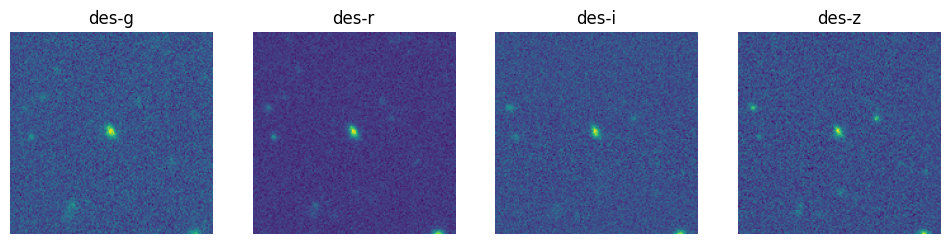

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    axes[i].imshow(flux[i], cmap="viridis")
    axes[i].set_title(sample["image"]["band"][i])
    axes[i].axis("off")

plt.show()

In [14]:
model = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)
model.eval()

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

In [15]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_tensor = transform(sample["rgb"]).unsqueeze(0)

print(image_tensor.shape)

torch.Size([1, 3, 224, 224])


In [16]:
with torch.no_grad():
    features = model.forward_features(image_tensor)

print(features.keys())

dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


In [19]:
print("CLS shape:", cls_token.shape)
print("Patch tokens shape:", patch_tokens.shape)

CLS shape: torch.Size([1, 384])
Patch tokens shape: torch.Size([1, 256, 384])


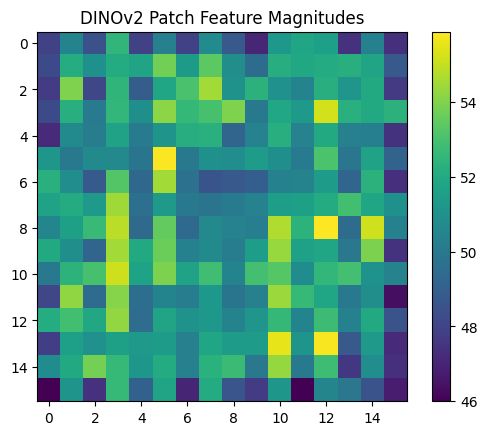

In [20]:
patch_grid = patch_tokens[0].norm(dim=1).reshape(16, 16)

plt.imshow(patch_grid)
plt.title("DINOv2 Patch Feature Magnitudes")
plt.colorbar()
plt.show()

In [21]:
sample2 = next(iter(dataset))

image2 = sample2["rgb"]
image2_tensor = transform(image2).unsqueeze(0)

print(image2_tensor.shape)

torch.Size([1, 3, 224, 224])


In [23]:
with torch.no_grad():
    features2 = model.forward_features(image2_tensor)

cls_token2 = features2["x_norm_clstoken"]

print("Galaxy 1:", cls_token.shape)

print("Galaxy 2:", cls_token2.shape)

Galaxy 1: torch.Size([1, 384])
Galaxy 2: torch.Size([1, 384])


In [24]:
similarity = torch.nn.functional.cosine_similarity(
    cls_token,
    cls_token2
)

print("Cosine similarity:", similarity.item())

Cosine similarity: 1.0000001192092896
